Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported successfully

✅ Data loaded successfully
Shape: (4707, 19)
Columns: ['TRANSFORMER_CODE', 'TRANSFORMER_LAT', 'TRANSFORMER_LON', 'ACCOUNT_NO', 'CUSTOMER_LAT', 'CUSTOMER_LON', 'MONTH', 'YEAR', 'IMPORT_kWh', 'EXPORT_kWh', 'NET_CONSUMPTION_kWh', 'HAS_SOLAR', 'INV_CAPACITY', 'CAL_TARIFF', 'PHASE', 'DATA_QUALITY', 'DISTANCE_FROM_TF_M', 'SOURCE', 'CONSUMPTION_LEVEL']

📊 BASIC DATASET INFORMATION

📈 Total Records: 4,707
🏠 Unique Households: 389
📅 Year Range: 2025-2025
📅 Months covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
⚡ Transformers: 10

📊 Data Types:
TRANSFORMER_CODE        object
TRANSFORMER_LAT        float64
TRANSFORMER_LON        float64
ACCOUNT_NO               int64
CUSTOMER_LAT           float64
CUSTOMER_LON       

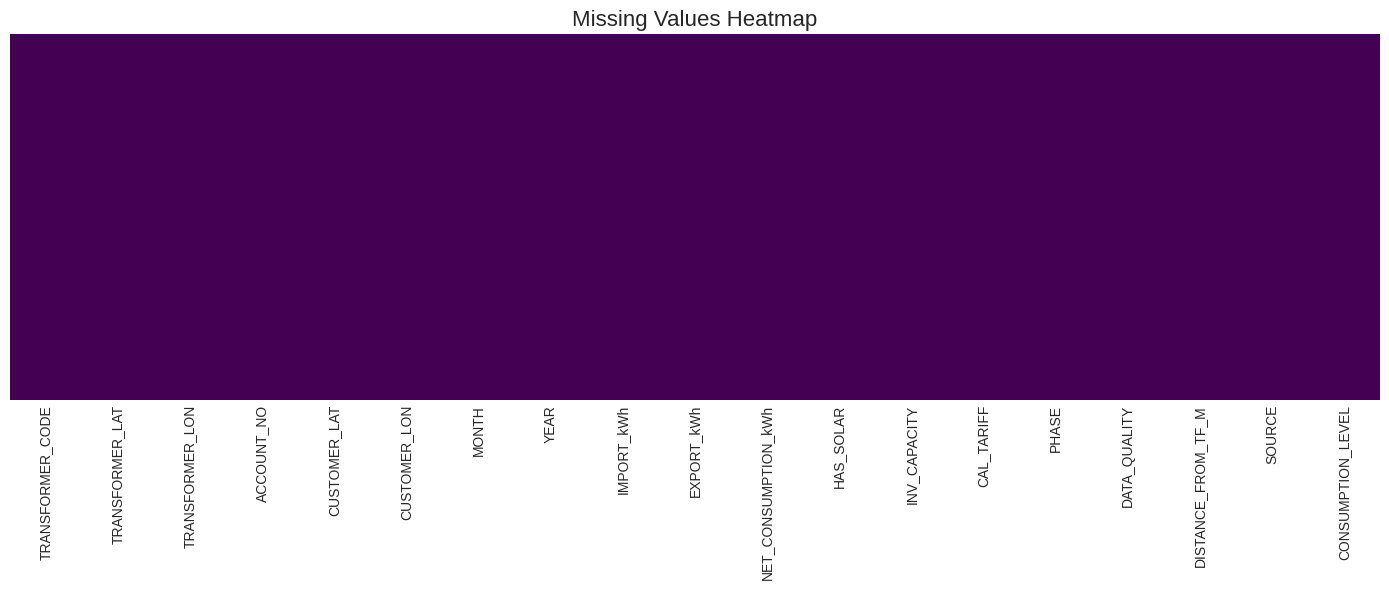


🎯 Target variable (NET_CONSUMPTION_kWh) NaN count: 0
✅ Target has no NaN values - good!

📊 CONSUMPTION DISTRIBUTION ANALYSIS


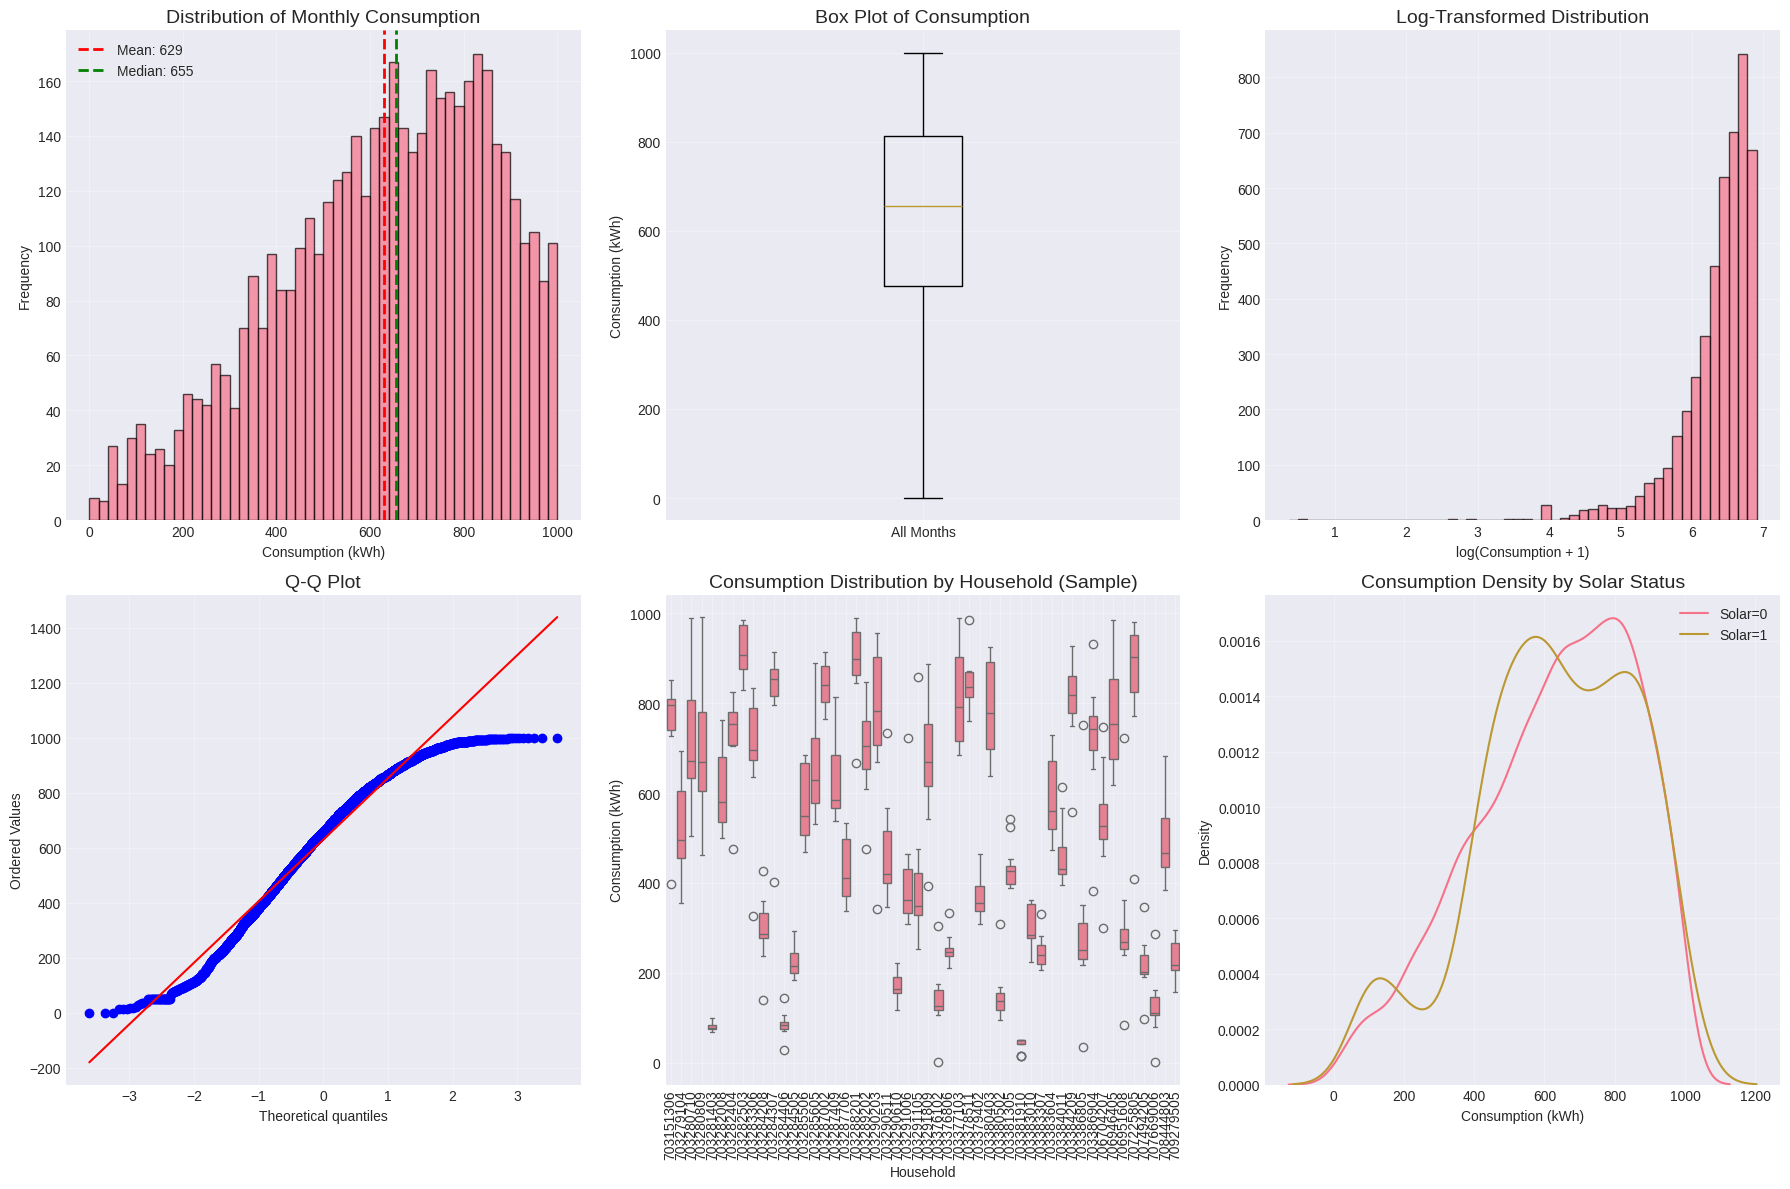


🔍 OUTLIER DETECTION
Lower bound: -29.86 kWh
Upper bound: 1317.34 kWh
Number of outliers: 0 (0.00%)
Z-score outliers (>3σ): 0 (0.00%)


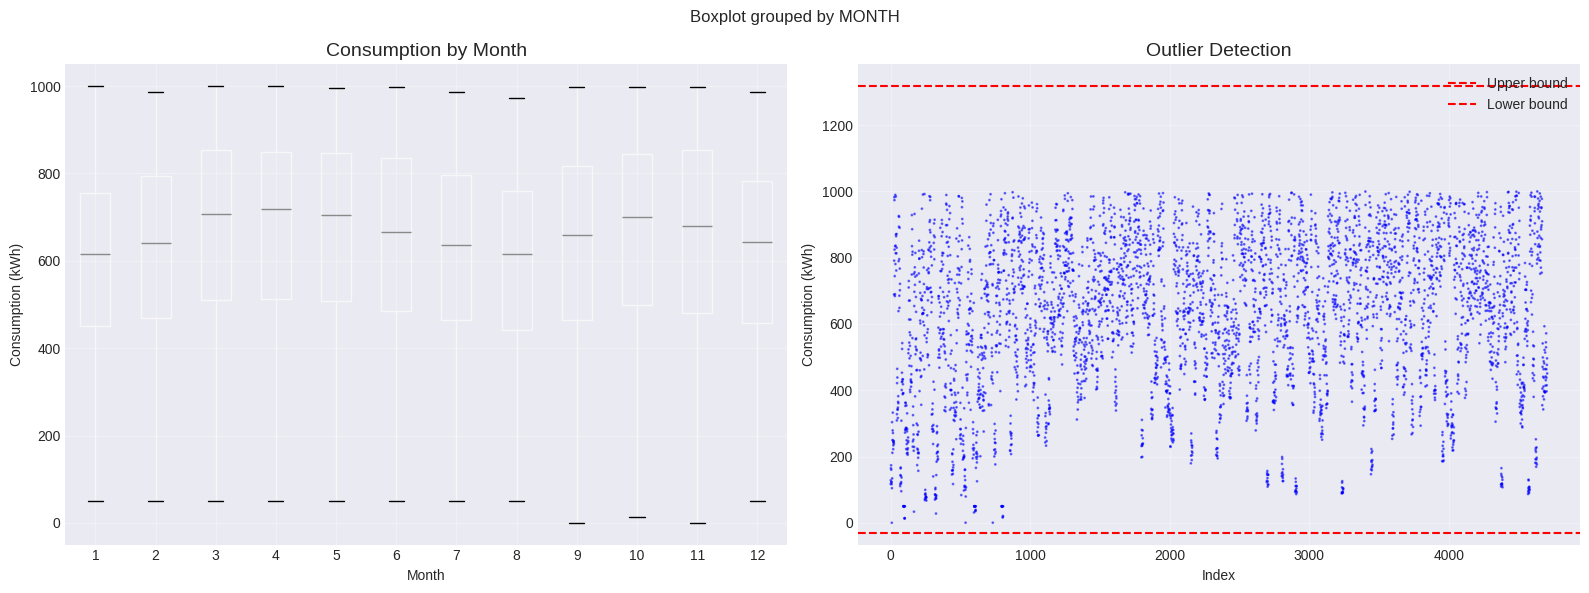


🌦️ SEASONAL PATTERN ANALYSIS

📊 Monthly Statistics:
             mean   median         std  count
MONTH                                        
1      587.754539  615.910  210.180594    434
2      616.954349  641.930  222.034790    430
3      664.940087  706.640  233.253135    345
4      668.049020  719.250  233.103716    296
5      660.012184  705.120  232.579887    316
6      641.241810  665.235  230.745775    420
7      614.172634  636.510  219.875915    429
8      584.361439  614.770  208.902635    431
9      626.771505  658.595  233.755183    412
10     655.659652  699.490  234.803329    374
11     650.462321  680.200  237.832161    392
12     611.066636  642.750  218.406401    428


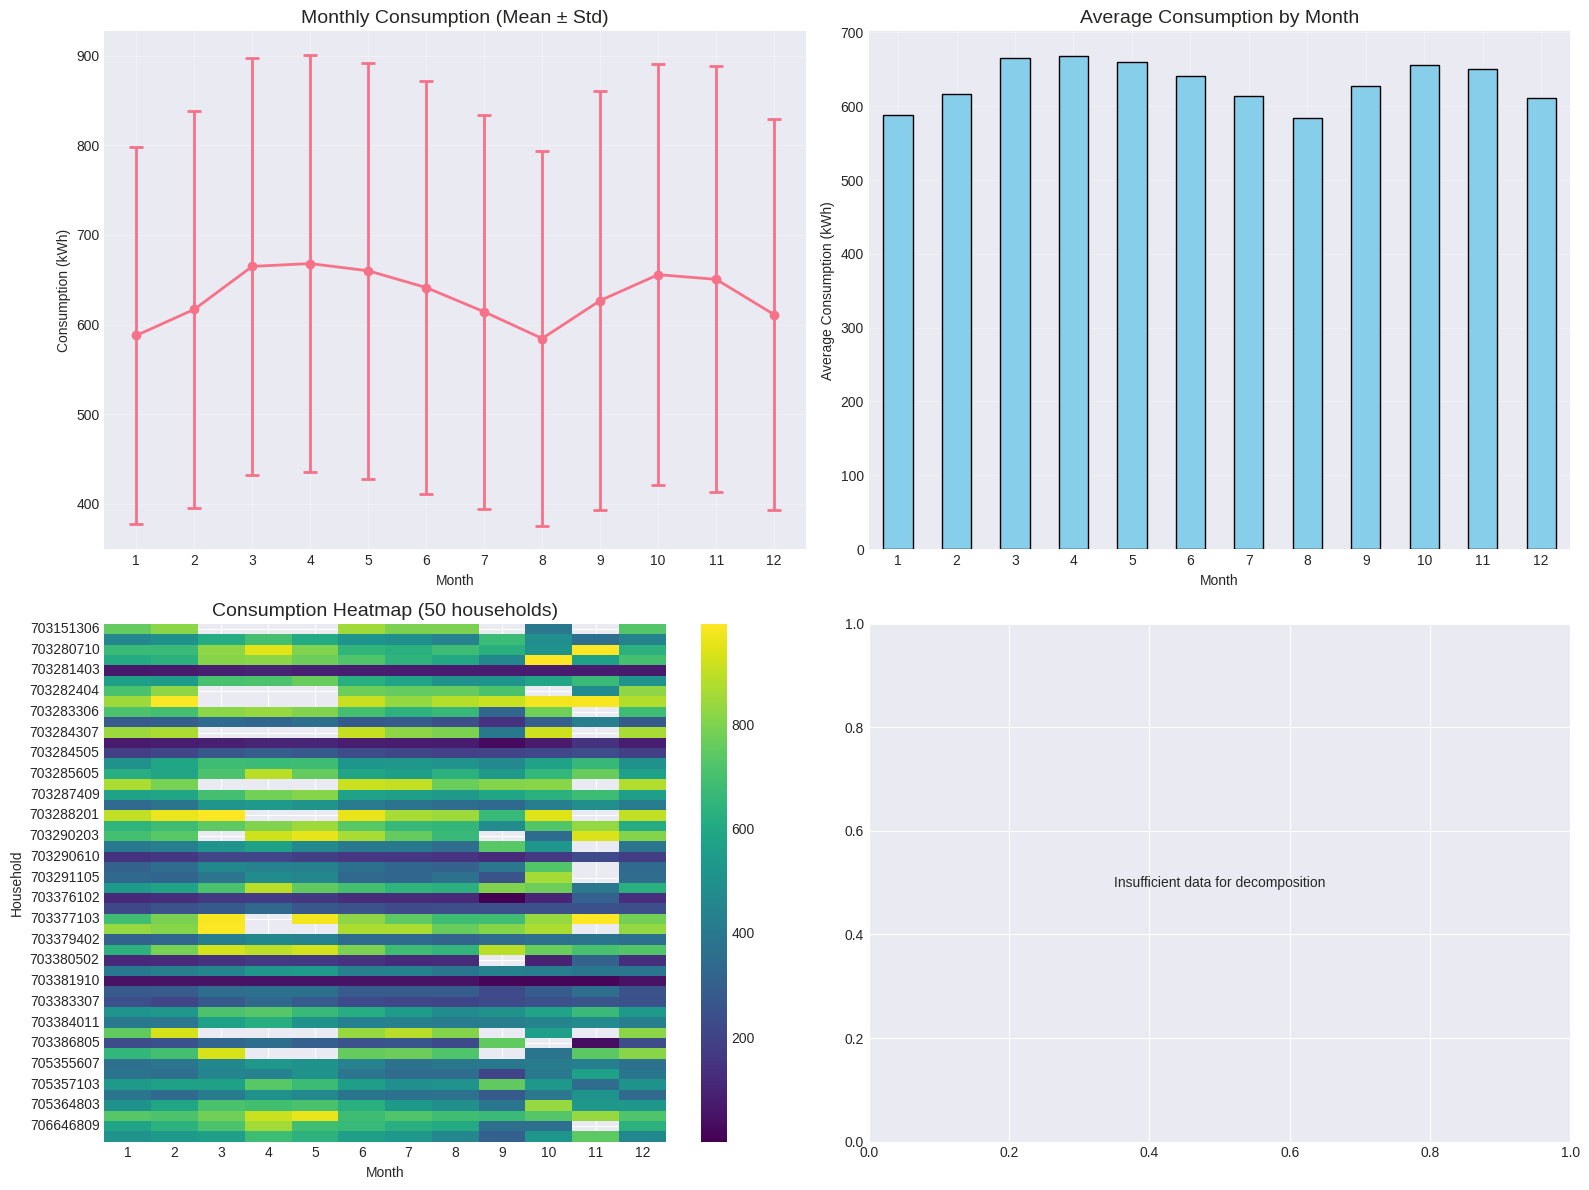


🗺️ GEOGRAPHIC ANALYSIS
Invalid latitudes: 0
Invalid longitudes: 0


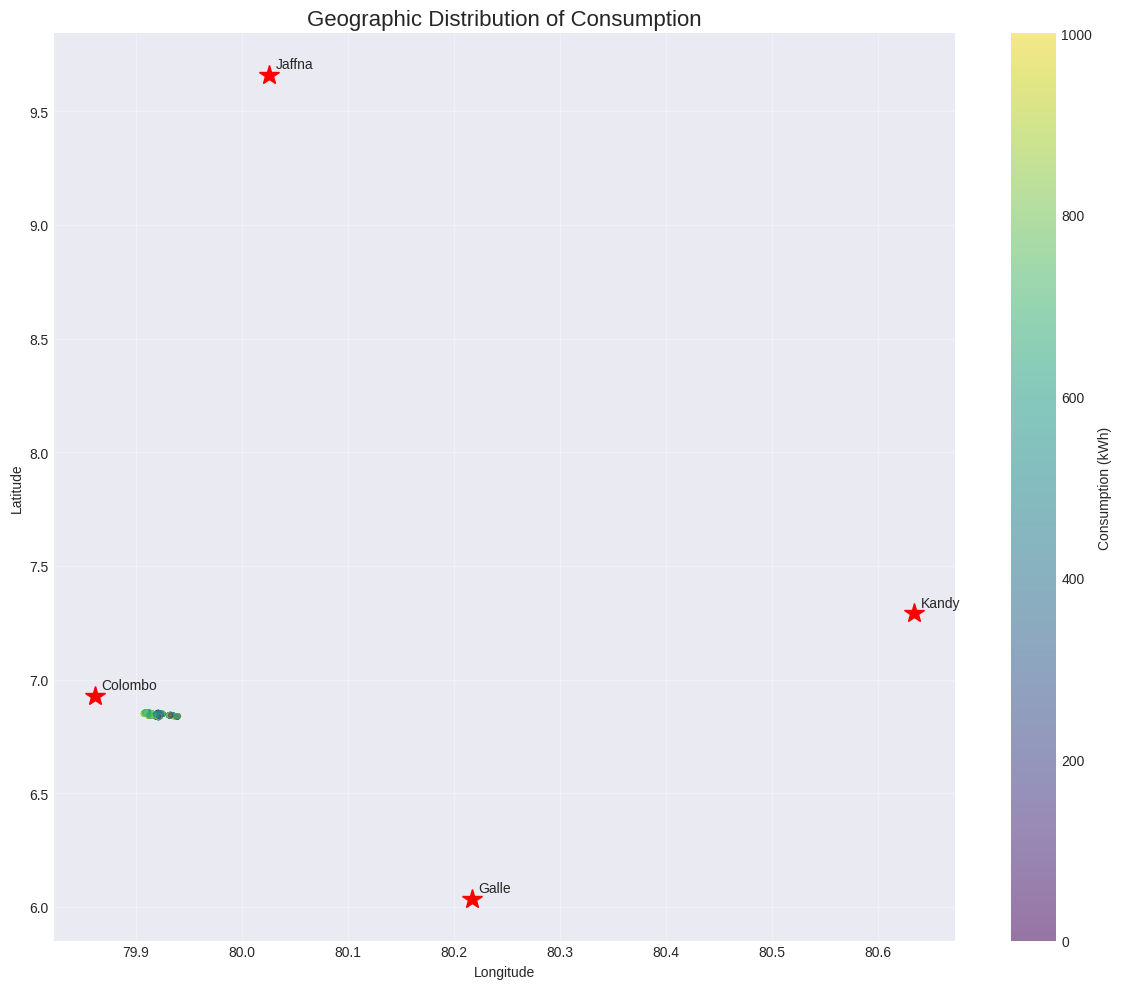


☀️ SOLAR VS NON-SOLAR HOUSEHOLDS
Solar households: 36 (9.25%)
Non-solar households: 363 (93.32%)


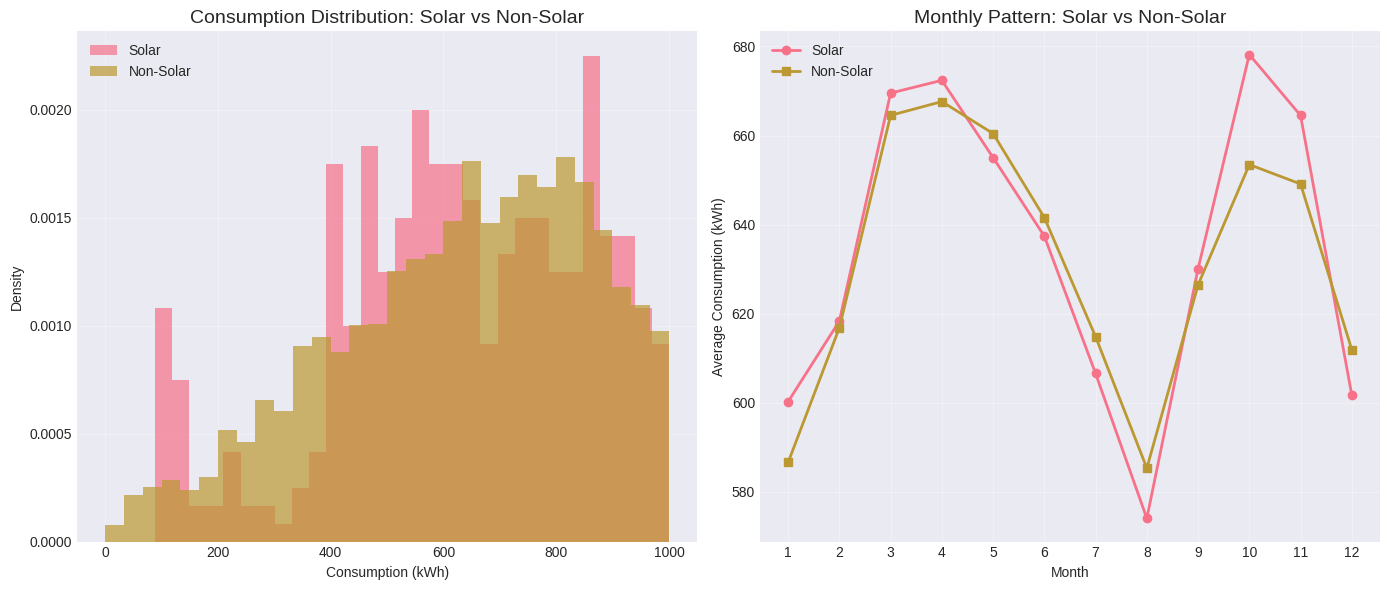


📊 T-test between solar and non-solar consumption:
   t-statistic: 0.2117
   p-value: 0.8323
   No significant difference

💰 TARIFF DISTRIBUTION
CAL_TARIFF
D1      2043
GP12    1342
GP11    1322
Name: count, dtype: int64


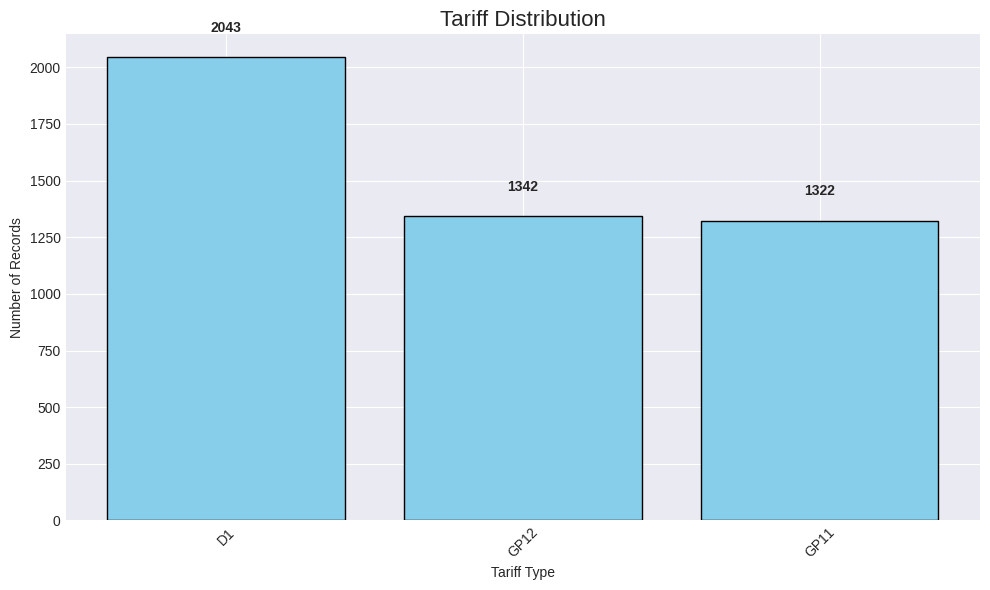


📊 Consumption statistics by tariff:
   D1: Mean=595.9, Median=631.4, Std=241.2
   GP11: Mean=654.3, Median=677.5, Std=212.6
   GP12: Mean=654.5, Median=681.2, Std=212.3

🔗 CORRELATION ANALYSIS


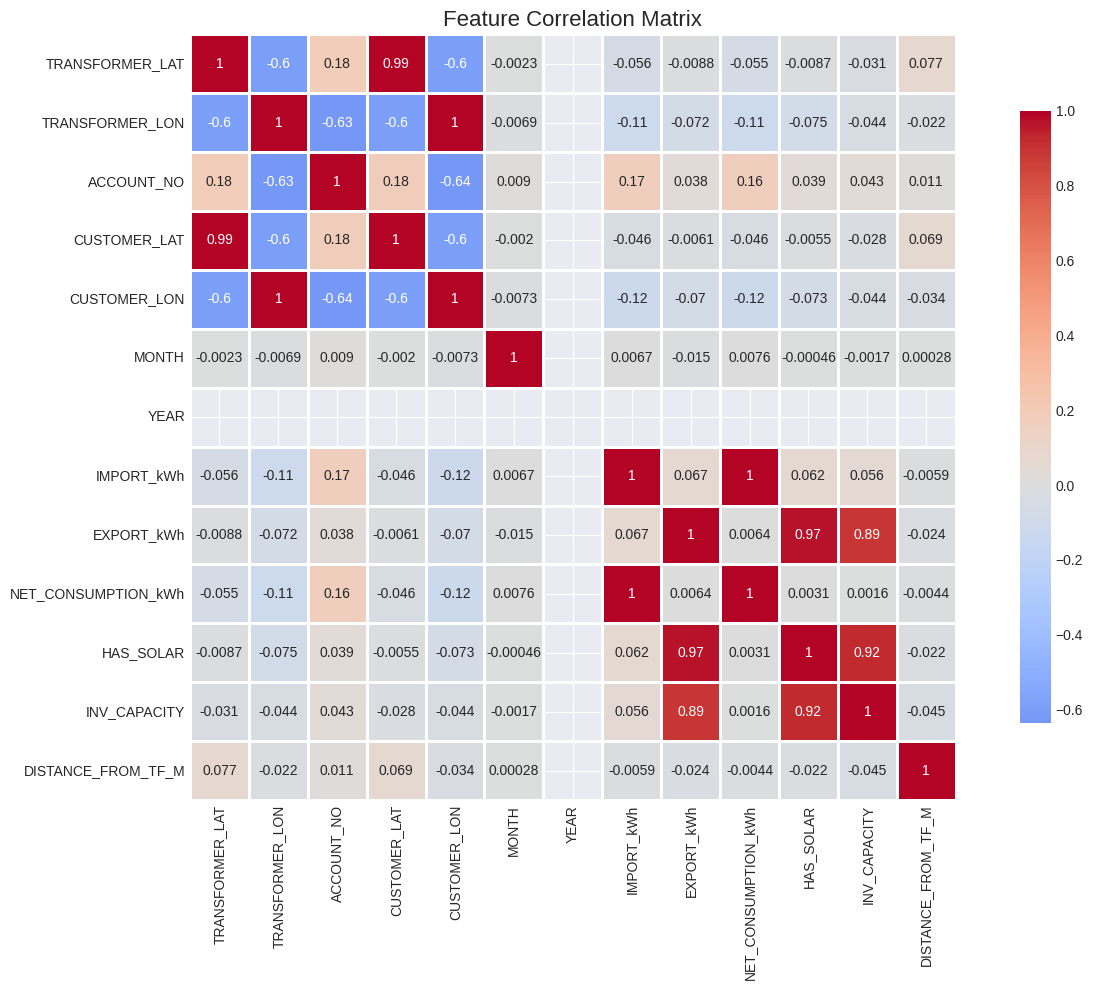


📊 Features most correlated with consumption:
NET_CONSUMPTION_kWh    1.000000
IMPORT_kWh             0.998156
ACCOUNT_NO             0.163085
MONTH                  0.007579
EXPORT_kWh             0.006354
HAS_SOLAR              0.003087
INV_CAPACITY           0.001575
DISTANCE_FROM_TF_M    -0.004398
CUSTOMER_LAT          -0.046091
TRANSFORMER_LAT       -0.055314
TRANSFORMER_LON       -0.107595
CUSTOMER_LON          -0.115615
YEAR                        NaN
Name: NET_CONSUMPTION_kWh, dtype: float64

🏠 HOUSEHOLD-LEVEL ANALYSIS
            avg_consumption  std_consumption  min_consumption  \
ACCOUNT_NO                                                      
703151306             734.8            154.3            397.6   
703279104             523.0            101.9            356.2   
703280710             719.8            142.5            503.7   
703280809             692.8            140.9            463.0   
703281403              79.3              9.1             67.5   
703282008    

In [ ]:
"""
# 01 - Exploratory Data Analysis (EDA)
## LECO Electricity Consumption Dataset - Sri Lanka

**Purpose**: Understand the structure, patterns, and quality of the LECO consumption data
"""

# 1. SETUP AND IMPORTS

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully")

# 2. LOAD DATA
# Data path
DATA_PATH = "/content/drive/MyDrive/DSGP_Group16_25 26/processed_new/MASTER_DATASET_RESIDENTIAL_ONLY.csv"

# Load data
df = pd.read_csv(DATA_PATH)
print(f"\nData loaded successfully")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# 3. BASIC DATA EXPLORATION
print("\n" + "="*60)
print("BASIC DATASET INFORMATION")
print("="*60)

print(f"\nTotal Records: {len(df):,}")
print(f"Unique Households: {df['ACCOUNT_NO'].nunique():,}")
print(f"Year Range: {df['YEAR'].min()}-{df['YEAR'].max()}")
print(f"Months covered: {sorted(df['MONTH'].unique())}")
print(f"Transformers: {df['TRANSFORMER_CODE'].nunique()}")

print("\nData Types:")
print(df.dtypes)

print("\nConsumption Statistics:")
print(df['NET_CONSUMPTION_kWh'].describe())

# First few rows
print("\nFirst 5 rows:")
df.head()

# 4. MISSING VALUES ANALYSIS
print("\n" + "="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percentage': missing_pct.values
}).sort_values('Missing', ascending=False)

print(missing_df[missing_df['Missing'] > 0])

# Visualize missing values
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Check target variable specifically
target_nan = df['NET_CONSUMPTION_kWh'].isna().sum()
print(f"\nTarget variable (NET_CONSUMPTION_kWh) NaN count: {target_nan}")

if target_nan > 0:
    print(f"WARNING: Target has {target_nan} NaN values! These must be handled.")
else:
    print("Target has no NaN values - good!")

# 5. CONSUMPTION DISTRIBUTION ANALYSIS
print("\n" + "="*60)
print("CONSUMPTION DISTRIBUTION ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 5.1 Histogram
axes[0,0].hist(df['NET_CONSUMPTION_kWh'], bins=50, edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['NET_CONSUMPTION_kWh'].mean(), color='red', linestyle='--',
                  linewidth=2, label=f'Mean: {df["NET_CONSUMPTION_kWh"].mean():.0f}')
axes[0,0].axvline(df['NET_CONSUMPTION_kWh'].median(), color='green', linestyle='--',
                  linewidth=2, label=f'Median: {df["NET_CONSUMPTION_kWh"].median():.0f}')
axes[0,0].set_title('Distribution of Monthly Consumption', fontsize=14)
axes[0,0].set_xlabel('Consumption (kWh)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 5.2 Box plot
axes[0,1].boxplot(df['NET_CONSUMPTION_kWh'])
axes[0,1].set_title('Box Plot of Consumption', fontsize=14)
axes[0,1].set_ylabel('Consumption (kWh)')
axes[0,1].set_xticklabels(['All Months'])
axes[0,1].grid(True, alpha=0.3)

# 5.3 Log transform
axes[0,2].hist(np.log1p(df['NET_CONSUMPTION_kWh']), bins=50, edgecolor='black', alpha=0.7)
axes[0,2].set_title('Log-Transformed Distribution', fontsize=14)
axes[0,2].set_xlabel('log(Consumption + 1)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].grid(True, alpha=0.3)

# 5.4 Q-Q plot for normality
stats.probplot(df['NET_CONSUMPTION_kWh'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot', fontsize=14)
axes[1,0].grid(True, alpha=0.3)

# 5.5 Box plot by household (first 50)
sample_accounts = df['ACCOUNT_NO'].unique()[:50]
sample_df = df[df['ACCOUNT_NO'].isin(sample_accounts)]
sns.boxplot(data=sample_df, x='ACCOUNT_NO', y='NET_CONSUMPTION_kWh', ax=axes[1,1])
axes[1,1].set_title('Consumption Distribution by Household (Sample)', fontsize=14)
axes[1,1].set_xlabel('Household')
axes[1,1].set_ylabel('Consumption (kWh)')
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].grid(True, alpha=0.3)

# 5.6 Density plot by solar status
for solar in [0, 1]:
    data = df[df['HAS_SOLAR'] == solar]['NET_CONSUMPTION_kWh']
    sns.kdeplot(data=data, label=f'Solar={solar}', ax=axes[1,2])
axes[1,2].set_title('Consumption Density by Solar Status', fontsize=14)
axes[1,2].set_xlabel('Consumption (kWh)')
axes[1,2].set_ylabel('Density')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. OUTLIER DETECTION
print("\n" + "="*60)
print("OUTLIER DETECTION")
print("="*60)

# IQR method
Q1 = df['NET_CONSUMPTION_kWh'].quantile(0.25)
Q3 = df['NET_CONSUMPTION_kWh'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['NET_CONSUMPTION_kWh'] < lower_bound) |
              (df['NET_CONSUMPTION_kWh'] > upper_bound)]

print(f"Lower bound: {lower_bound:.2f} kWh")
print(f"Upper bound: {upper_bound:.2f} kWh")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Z-score method
z_scores = np.abs(stats.zscore(df['NET_CONSUMPTION_kWh'].dropna()))
z_outliers = df.iloc[np.where(z_scores > 3)[0]]
print(f"Z-score outliers (>3σ): {len(z_outliers)} ({len(z_outliers)/len(df)*100:.2f}%)")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot by month
df.boxplot(column='NET_CONSUMPTION_kWh', by='MONTH', ax=axes[0])
axes[0].set_title('Consumption by Month', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Consumption (kWh)')
axes[0].grid(True, alpha=0.3)

# Scatter plot with outlier highlighting
colors = ['red' if (x < lower_bound or x > upper_bound) else 'blue'
          for x in df['NET_CONSUMPTION_kWh']]
axes[1].scatter(range(len(df)), df['NET_CONSUMPTION_kWh'], c=colors, alpha=0.5, s=1)
axes[1].axhline(y=upper_bound, color='red', linestyle='--', label='Upper bound')
axes[1].axhline(y=lower_bound, color='red', linestyle='--', label='Lower bound')
axes[1].set_title('Outlier Detection', fontsize=14)
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Consumption (kWh)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7. SEASONAL PATTERN ANALYSIS
print("\n" + "="*60)
print("SEASONAL PATTERN ANALYSIS")
print("="*60)

# Monthly averages
monthly_avg = df.groupby('MONTH')['NET_CONSUMPTION_kWh'].agg(['mean', 'median', 'std', 'count'])
monthly_avg = monthly_avg.reindex(range(1, 13))

print("\nMonthly Statistics:")
print(monthly_avg)

# Visualize monthly patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Monthly averages with error bars
axes[0,0].errorbar(monthly_avg.index, monthly_avg['mean'],
                   yerr=monthly_avg['std'], marker='o', capsize=5, capthick=2, linewidth=2)
axes[0,0].set_title('Monthly Consumption (Mean ± Std)', fontsize=14)
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Consumption (kWh)')
axes[0,0].set_xticks(range(1, 13))
axes[0,0].grid(True, alpha=0.3)

# Bar plot
monthly_avg['mean'].plot(kind='bar', ax=axes[0,1], color='skyblue', edgecolor='black')
axes[0,1].set_title('Average Consumption by Month', fontsize=14)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Average Consumption (kWh)')
axes[0,1].set_xticklabels(range(1, 13), rotation=0)
axes[0,1].grid(True, alpha=0.3)

# Heatmap of consumption by month
pivot_monthly = df.pivot_table(values='NET_CONSUMPTION_kWh',
                                index='ACCOUNT_NO',
                                columns='MONTH',
                                aggfunc='mean')
sns.heatmap(pivot_monthly.iloc[:50, :], cmap='viridis', ax=axes[1,0])
axes[1,0].set_title('Consumption Heatmap (50 households)', fontsize=14)
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Household')

# Seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Get one household's time series
sample_account = df['ACCOUNT_NO'].iloc[0]
sample_data = df[df['ACCOUNT_NO'] == sample_account].sort_values(['YEAR', 'MONTH'])

if len(sample_data) >= 24:
    # Create a date range
    dates = pd.date_range(start=f"{sample_data['YEAR'].iloc[0]}-{sample_data['MONTH'].iloc[0]}-01",
                          periods=len(sample_data), freq='M')
    ts = pd.Series(sample_data['NET_CONSUMPTION_kWh'].values, index=dates)

    try:
        decomposition = seasonal_decompose(ts, model='additive', period=12)
        decomposition.plot()
        axes[1,1].set_title('Seasonal Decomposition', fontsize=14)
    except:
        axes[1,1].text(0.5, 0.5, 'Could not decompose',
                       ha='center', va='center', transform=axes[1,1].transAxes)
else:
    axes[1,1].text(0.5, 0.5, 'Insufficient data for decomposition',
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.show()

# 8. GEOGRAPHIC ANALYSIS
print("\n" + "="*60)
print("GEOGRAPHIC ANALYSIS")
print("="*60)

# Check Sri Lanka bounds
sri_lanka_bounds = {
    'lat_min': 5.9, 'lat_max': 9.8,
    'lon_min': 79.6, 'lon_max': 81.9
}

invalid_lat = df[(df['CUSTOMER_LAT'] < sri_lanka_bounds['lat_min']) |
                 (df['CUSTOMER_LAT'] > sri_lanka_bounds['lat_max'])]
invalid_lon = df[(df['CUSTOMER_LON'] < sri_lanka_bounds['lon_min']) |
                 (df['CUSTOMER_LON'] > sri_lanka_bounds['lon_max'])]

print(f"Invalid latitudes: {len(invalid_lat)}")
print(f"Invalid longitudes: {len(invalid_lon)}")

# Geographic scatter plot
fig, ax = plt.subplots(figsize=(12, 10))

# Sample for plotting
sample_df = df.sample(min(5000, len(df)))

scatter = ax.scatter(sample_df['CUSTOMER_LON'], sample_df['CUSTOMER_LAT'],
                     c=sample_df['NET_CONSUMPTION_kWh'], cmap='viridis',
                     alpha=0.5, s=10, vmin=0, vmax=1000)
plt.colorbar(scatter, ax=ax, label='Consumption (kWh)')
ax.set_title('Geographic Distribution of Consumption', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Add major cities
cities = {
    'Colombo': (6.9271, 79.8612),
    'Kandy': (7.2906, 80.6337),
    'Galle': (6.0329, 80.2168),
    'Jaffna': (9.6615, 80.0255)
}

for city, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'r*', markersize=15)
    ax.annotate(city, (lon, lat), xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


# 9. SOLAR VS NON-SOLAR ANALYSIS
print("\n" + "="*60)
print("SOLAR VS NON-SOLAR HOUSEHOLDS")
print("="*60)

solar_count = df[df['HAS_SOLAR'] == 1]['ACCOUNT_NO'].nunique()
non_solar_count = df[df['HAS_SOLAR'] == 0]['ACCOUNT_NO'].nunique()
total_households = df['ACCOUNT_NO'].nunique()

print(f"Solar households: {solar_count} ({solar_count/total_households*100:.2f}%)")
print(f"Non-solar households: {non_solar_count} ({non_solar_count/total_households*100:.2f}%)")

# Compare consumption patterns
solar_consumption = df[df['HAS_SOLAR'] == 1]['NET_CONSUMPTION_kWh']
non_solar_consumption = df[df['HAS_SOLAR'] == 0]['NET_CONSUMPTION_kWh']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution comparison
axes[0].hist(solar_consumption, bins=30, alpha=0.7, label='Solar', density=True)
axes[0].hist(non_solar_consumption, bins=30, alpha=0.7, label='Non-Solar', density=True)
axes[0].set_title('Consumption Distribution: Solar vs Non-Solar', fontsize=14)
axes[0].set_xlabel('Consumption (kWh)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Monthly comparison
solar_monthly = df[df['HAS_SOLAR'] == 1].groupby('MONTH')['NET_CONSUMPTION_kWh'].mean()
non_solar_monthly = df[df['HAS_SOLAR'] == 0].groupby('MONTH')['NET_CONSUMPTION_kWh'].mean()

axes[1].plot(solar_monthly.index, solar_monthly.values, 'o-', label='Solar', linewidth=2)
axes[1].plot(non_solar_monthly.index, non_solar_monthly.values, 's-', label='Non-Solar', linewidth=2)
axes[1].set_title('Monthly Pattern: Solar vs Non-Solar', fontsize=14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Consumption (kWh)')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical test
t_stat, p_value = stats.ttest_ind(solar_consumption, non_solar_consumption)
print(f"\nT-test between solar and non-solar consumption:")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value:.4f}")
print(f"   {'Significant difference' if p_value < 0.05 else 'No significant difference'}")


# 10. TARIFF ANALYSIS
print("\n" + "="*60)
print("TARIFF DISTRIBUTION")
print("="*60)

tariff_dist = df['CAL_TARIFF'].value_counts()
print(tariff_dist)

# Plot tariff distribution
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(tariff_dist.index, tariff_dist.values, color='skyblue', edgecolor='black')
ax.set_title('Tariff Distribution', fontsize=16)
ax.set_xlabel('Tariff Type')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Consumption by tariff
print("\nConsumption statistics by tariff:")
for tariff in df['CAL_TARIFF'].unique():
    tariff_data = df[df['CAL_TARIFF'] == tariff]['NET_CONSUMPTION_kWh']
    print(f"   {tariff}: Mean={tariff_data.mean():.1f}, Median={tariff_data.median():.1f}, Std={tariff_data.std():.1f}")

# 11. CORRELATION ANALYSIS
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Find correlations with consumption
consumption_corr = corr_matrix['NET_CONSUMPTION_kWh'].sort_values(ascending=False)
print("\nFeatures most correlated with consumption:")
print(consumption_corr)

# 12. HOUSEHOLD-LEVEL ANALYSIS
print("\n" + "="*60)
print("HOUSEHOLD-LEVEL ANALYSIS")
print("="*60)

# Calculate household statistics
household_stats = df.groupby('ACCOUNT_NO').agg({
    'NET_CONSUMPTION_kWh': ['mean', 'std', 'min', 'max', 'count'],
    'HAS_SOLAR': 'first',
    'CAL_TARIFF': 'first'
}).round(1)

household_stats.columns = ['avg_consumption', 'std_consumption', 'min_consumption',
                          'max_consumption', 'n_months', 'has_solar', 'tariff']
print(household_stats.head(10))

print(f"\nHousehold statistics summary:")
print(f"   Average consumption range: {household_stats['avg_consumption'].min():.1f} - {household_stats['avg_consumption'].max():.1f} kWh")
print(f"   Households with high variability (std > 100): {(household_stats['std_consumption'] > 100).sum()}")
print(f"   Households with complete data (12 months): {(household_stats['n_months'] == 12).sum()}")

# 13. KEY FINDINGS FOR MODELING
print("\n" + "="*60)
print("KEY FINDINGS & CONCLUSIONS")
print("="*60)

# Calculate metrics for summary
total_records = len(df)
unique_hh = df['ACCOUNT_NO'].nunique()
missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
outlier_pct = len(outliers) / len(df) * 100

monthly_means = df.groupby('MONTH')['NET_CONSUMPTION_kWh'].mean()
peak_months = monthly_means.nlargest(3).index.tolist()
low_months = monthly_means.nsmallest(3).index.tolist()
april_boost = (monthly_means[4] / monthly_means.mean() - 1) * 100
monsoon_drop = (1 - monthly_means[[7,8]].mean() / monthly_means.mean()) * 100

solar_pct = (df[df['HAS_SOLAR'] == 1]['ACCOUNT_NO'].nunique() / unique_hh) * 100
solar_mean = df[df['HAS_SOLAR'] == 1]['NET_CONSUMPTION_kWh'].mean()
non_solar_mean = df[df['HAS_SOLAR'] == 0]['NET_CONSUMPTION_kWh'].mean()
solar_vs_non = abs(solar_mean - non_solar_mean) / non_solar_mean * 100
solar_comparison = "higher" if solar_mean > non_solar_mean else "lower"

urban = df[(df['CUSTOMER_LAT'] > 6.8) & (df['CUSTOMER_LAT'] < 7.0) &
           (df['CUSTOMER_LON'] > 79.8) & (df['CUSTOMER_LON'] < 80.0)]
rural = df[~((df['CUSTOMER_LAT'] > 6.8) & (df['CUSTOMER_LAT'] < 7.0) &
             (df['CUSTOMER_LON'] > 79.8) & (df['CUSTOMER_LON'] < 80.0))]
urban_vs_rural = (urban['NET_CONSUMPTION_kWh'].mean() / rural['NET_CONSUMPTION_kWh'].mean() - 1) * 100

findings = f"""
DATA QUALITY:
• Total records: {total_records:,}
• Unique households: {unique_hh:,}
• Missing values: {missing_pct:.2f}% of data
• Outliers detected: {outlier_pct:.2f}% of records

SEASONAL PATTERNS:
• Peak consumption months: {peak_months}
• Lowest consumption months: {low_months}
• April shows {april_boost:.1f}% higher consumption than average
• Monsoon months (Jul-Aug) show {monsoon_drop:.1f}% lower consumption

SOLAR IMPACT:
• Solar penetration: {solar_pct:.2f}%
• Solar households consume {solar_vs_non:.1f}% {solar_comparison} than non-solar

GEOGRAPHIC:
• Major cities have {urban_vs_rural:.1f}% higher consumption

ISSUES TO ADDRESS IN MODELING:
1. Wide consumption range ({df['NET_CONSUMPTION_kWh'].min():.0f}-{df['NET_CONSUMPTION_kWh'].max():.0f} kWh) - model must predict full range
2. High variability between households (std: {df['NET_CONSUMPTION_kWh'].std():.0f} kWh)
3. Seasonal patterns need to be captured
4. Solar vs non-solar have different patterns
5. Missing values must be handled ({missing.sum()} total)

RECOMMENDED FEATURES:
• Historical rolling averages (3, 6, 12 months)
• Consumption trends (increasing/decreasing)
• Volatility measures (rolling std)
• Solar status and tariff information
• Month (cyclical encoding)
• Geographic features (distance from transformer)
"""

print(findings)


# 14. SAVE CLEANED DATA
# Save cleaned data for next notebooks
# df.to_csv('cleaned_consumption_data.csv', index=False)
# print("\nCleaned data saved to 'cleaned_consumption_data.csv'")

print("\n" + "="*60)
print("EDA COMPLETE")
print("="*60)